# Figures 4 and 5: 4D-Var State Estimation and Analysis Skill

In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.ticker import AutoMinorLocator
import os

# os.chdir('../../')  # Change to main project directory
# === Read in processed data ===

# 1. Background state distances (if needed for other analyses)
df_xb_distances = pd.read_csv('./data/processed_assimilation_data/background_state_distances.csv')

# 2. Assimilation metrics (for boxplots)
df_flat = pd.read_csv('./data/processed_assimilation_data/assimilation_metrics.csv')

# 3. Aggregated skill scores (for skill plot)
df_skills_aggregated = pd.read_csv('./data/processed_assimilation_data/analysis_skills_aggregated.csv')

# === Recreate derived columns for boxplot ===
df_flat["log_runtime"] = np.log10(df_flat["runtime"])
df_flat["jo_jb_ratio"] = df_flat["jo_a"] / df_flat["jb_a"]
df_flat["log_jo_jb_ratio"] = np.log10(df_flat["jo_jb_ratio"])
df_flat["pct_drop_J_100"] = 100 * df_flat["pct_drop_J"]

# === Create melted format for boxplot ===
metrics_normal = ["runtime", "pct_drop_J_100", "log_jo_jb_ratio"]

df_long_normal = df_flat.melt(
    id_vars=["method", "dataset"],
    value_vars=metrics_normal,
    var_name="metric",
    value_name="value"
)

# Relabel metrics
df_long_normal["metric"] = df_long_normal["metric"].replace({
    "runtime": "Computational Time (s)",
    "pct_drop_J_100": "Cost Function Reduction (%)",
    "log_jo_jb_ratio": "log$_{10}(J_o/J_b)$"
})

# === Prepare skill data for plotting ===
# Filter out the global aggregate rows (time_days == -1) for time series plot
df_skills_timeseries = df_skills_aggregated[df_skills_aggregated["time_days"] >= 0]

# Extract global skills if needed for text/summary
df_skills_global = df_skills_aggregated[df_skills_aggregated["time_days"] == -1]

print("✓ Data loaded successfully")
print(f"  - Assimilation metrics: {df_flat.shape[0]} rows")
print(f"  - Skill time series: {df_skills_timeseries.shape[0]} rows")
print(f"  - Background distances: {df_xb_distances.shape[0]} rows")

# === Now you can create your figures ===
# Your boxplot code here...
# Your skill plot code here...

✓ Data loaded successfully
  - Assimilation metrics: 60000 rows
  - Skill time series: 2018 rows
  - Background distances: 30000 rows


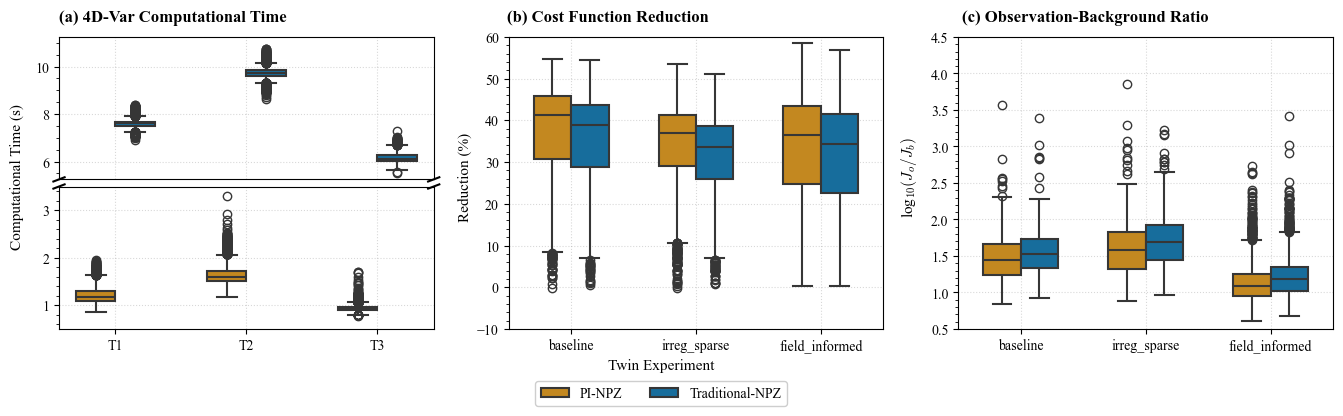

In [3]:
# === Typography ===
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# === Colors ===
trad_npz_color = "#0173B2"   # Traditional-NPZ (orange)
pinn_color     =  "#DE8F05"  # PI-NPZ (blue)
method_palette = {"Traditional-NPZ": trad_npz_color, "PI-NPZ": pinn_color}


# --- Runtime subset ---
df_runtime = df_long_normal[df_long_normal["metric"] == "Computational Time (s)"]

# --- Create figure with GridSpec ---
fig = plt.figure(figsize=(14, 4))
gs = gridspec.GridSpec(2, 3, figure=fig,
                       left=0.07, right=0.98,
                       top=0.88, bottom=0.15,
                       wspace=0.2, hspace=0.05)

panel_labels = ["(a)", "(b)", "(c)"]

# =========================================================
# (a) Assimilation Runtime (broken axis)
# =========================================================
ax_top = fig.add_subplot(gs[0, 0])
sns.boxplot(data=df_runtime, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_top)
ax_top.set_ylim(5.25, 11.25)
ax_top.set_ylabel(""); ax_top.set_xlabel("")
ax_top.tick_params(labelbottom=False, bottom=False, labelsize=10)
ax_top.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_top.yaxis.set_minor_locator(AutoMinorLocator())
if ax_top.get_legend() is not None:
    ax_top.get_legend().remove()

ax_bottom = fig.add_subplot(gs[1, 0], sharex=ax_top)
sns.boxplot(data=df_runtime, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_bottom)
ax_bottom.set_ylim(0.5, 3.5)
ax_bottom.set_xlabel(""); ax_bottom.set_ylabel("")
ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])
ax_bottom.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_bottom.tick_params(labelsize=10)
ax_bottom.yaxis.set_minor_locator(AutoMinorLocator())
if ax_bottom.get_legend() is not None:
    ax_bottom.get_legend().remove()

# Break marks
d = .015
for ax, pos in [(ax_bottom, 1), (ax_top, 0)]:
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((-d, +d), (pos-d, pos+d), **kwargs)
    ax.plot((1-d, 1+d), (pos-d, pos+d), **kwargs)

# =========================================================
# (b) Cost Reduction
# =========================================================
metric_data = df_long_normal[df_long_normal["metric"] == "Cost Function Reduction (%)"]
ax_b = fig.add_subplot(gs[:, 1])
sns.boxplot(data=metric_data, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_b)
ax_b.set_ylabel(""); ax_b.set_xlabel("")
ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])
ax_b.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_b.tick_params(labelsize=10)
ax_b.yaxis.set_minor_locator(AutoMinorLocator())
ax_b.set_ylim(-10, 60)
if ax_b.get_legend() is not None:
    ax_b.get_legend().remove()

# =========================================================
# (c) Observation Weight
# =========================================================
metric_data = df_long_normal[df_long_normal["metric"] == "log$_{10}(J_o/J_b)$"]
ax_c = fig.add_subplot(gs[:, 2])
sns.boxplot(data=metric_data, x="dataset", y="value", hue="method",
            palette=method_palette, width=0.6, linewidth=1.5, ax=ax_c)
ax_c.set_ylabel(""); ax_c.set_xlabel("")
ax_bottom.set_xticks(range(3))
ax_bottom.set_xticklabels(["T1", "T2", "T3"])
ax_c.grid(True, linestyle=":", alpha=0.3, color="gray")
ax_c.tick_params(labelsize=10)
ax_c.yaxis.set_minor_locator(AutoMinorLocator())
ax_c.set_ylim(0.5, 4.5)
if ax_c.get_legend() is not None:
    ax_c.get_legend().remove()

# =========================================================
# Panel Titles
# =========================================================
fig.text(0.07, 0.91, f"{panel_labels[0]} 4D-Var Computational Time",
         fontsize=12, fontweight='bold', ha='left', va='bottom')
fig.text(0.39, 0.91, f"{panel_labels[1]} Cost Function Reduction",
         fontsize=12, fontweight='bold', ha='left', va='bottom')
fig.text(0.715, 0.91, f"{panel_labels[2]} Observation-Background Ratio",
         fontsize=12, fontweight='bold', ha='left', va='bottom')

# =========================================================
# Figure-level y-labels
# =========================================================
fig.text(0.035, 0.53, "Computational Time (s)", fontsize=11, va='center', rotation='vertical')
fig.text(0.355, 0.53, "Reduction (%)", fontsize=11, va='center', rotation='vertical')
fig.text(0.67, 0.53, "log$_{10}(J_o/J_b)$", fontsize=11, va='center', rotation='vertical')

# Shared x-label
fig.text(0.5, 0.05, "Twin Experiment", fontsize=11, ha='center')

# =========================================================
# Shared Legend
# =========================================================
handles, labels = ax_bottom.get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', ncol=2,
           fontsize=10, framealpha=0.95,
           bbox_to_anchor=(0.5, -0.06))

# === Save ===
# base_path = "/Users/egank31/Documents/Documents - Otto/GitHub/pinns/npz/current/important_files_paper/figures/"
# file_base = "state_estimation_boxplots_broken_axis"

# for ext in ["pdf"]:
#     dpi = 600 if ext == "png" else None
#     plt.savefig(f"{base_path}{file_base}.{ext}",
#                 dpi=dpi, bbox_inches='tight',
#                 pad_inches=0.02, format=ext)

plt.show()


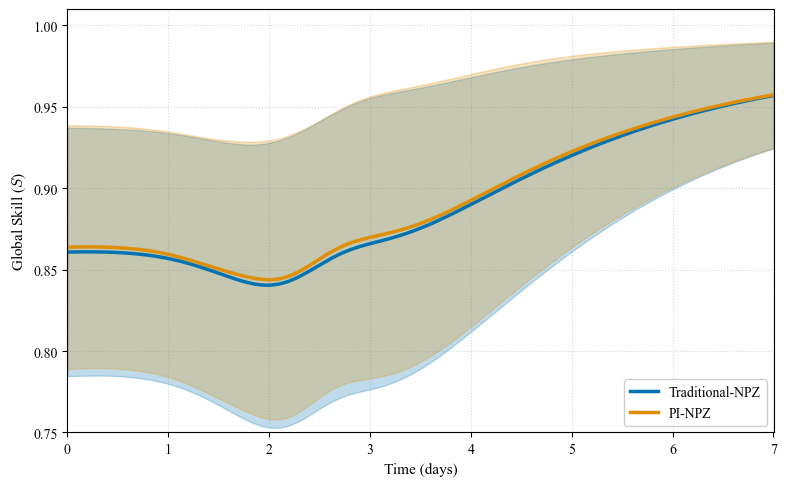

In [4]:
# Typography for JAMES publication
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False

# Axis and tick styling
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['text.color'] = 'black'

# Color scheme
colors = {"PI-NPZ": "#DE8F05", "Traditional-NPZ": "#0173B2"}

# === Single-panel figure ===
fig, ax = plt.subplots(figsize=(8, 5))

# Plot both methods
for method in ["Traditional-NPZ", "PI-NPZ"]:
    method_data = df_skills_timeseries[df_skills_timeseries["method"] == method]
    
    times = method_data["time_days"].values
    mean = method_data["skill_mean"].values
    std = method_data["skill_std"].values
    
    lower = np.clip(mean - std, 0.0, None)
    upper = np.minimum(mean + std, 1.0)
    
    ax.plot(times, mean, color=colors[method], linewidth=2.5, label=method)
    ax.fill_between(times, lower, upper, color=colors[method], alpha=0.25)

# Labels and formatting
ax.set_xlabel("Time (days)", fontsize=11)
ax.set_ylabel("Global Skill ($S$)", fontsize=11)
ax.set_xlim(0, 7)
ax.set_ylim(0.75, 1.01)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')
ax.legend(loc='lower right', fontsize=10, framealpha=0.95)

plt.tight_layout()

# # === Save in multiple formats ===
# base_path = "../figures/"
# file_base = "analysis_forecast_skill_comparison"

# for ext in ["pdf"]:
#     dpi = 600 if ext == "png" else None
#     plt.savefig(f"{base_path}{file_base}.{ext}", 
#                 dpi=dpi, 
#                 bbox_inches='tight', 
#                 pad_inches=0.02,
#                 format=ext)
    
plt.show()